In [5]:
using CSV, LaTeXStrings, PythonCall, KernelDensity, StatsBase
using PhysicalConstants.CODATA2018: c_0

include(string(@__DIR__, "/Source.jl"))
@py import matplotlib as mpl
@py import matplotlib.pyplot as plt

mpl.use("pgf")

Python: None

In [10]:
# import data
columns = ["start", "stop", "pulse_length", "doppler", "PMT_sum"]
[push!(columns, "PMT$i") for i in 1:100]
df = CSV.read(joinpath(@__DIR__, "PMT1_2_excel_NO_mean_exc.txt"), DataFrame, header=columns, delim="	", skipto=2)

x = 1:length(df[!, "PMT1"])

# collect all PMTs in one array
PMT_all = []
for i in 1:100
    push!(PMT_all, df[!, "PMT$i"])
end

PMT_mat = hcat(PMT_all...)
PMT_arr = vcat(PMT_all...)
# remove values > 100 
PMT_arr = PMT_arr[PMT_arr .< 100]

14067-element Vector{Int64}:
 46
 36
 42
 35
 31
 39
 11
 43
 53
 40
  ⋮
 36
 34
 48
  6
 10
 37
 11
  9
  8

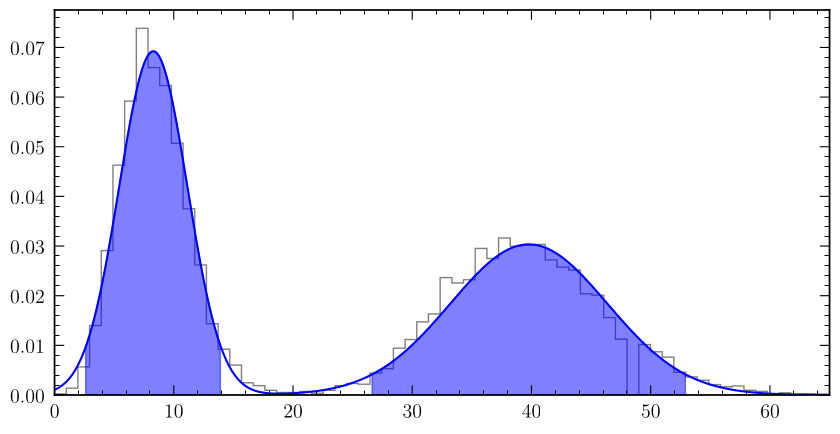

In [11]:
gauss(x, p) = @. p[1] * exp(-((x - p[2])^2) / (2 * p[3]^2)) + p[4] * exp(-(x - p[5])^2 / (2 * p[6]^2))
# fit Gaussian to array

h = fit(Histogram, PMT_arr, 0:1:100)
centers = h.edges[1][1:end-1] .+ diff(h.edges[1]) / 2
h.weights

popt, ci = bootstrap(gauss, centers, h.weights/sum(h.weights), p0=[.07, 10.0, 1.0, 0.03, 30., 5.], unc=true, redraw=false)

# plot as nice 2D histogram
# begin
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(PMT_arr, bins=100, histtype="stepfilled", color="white", edgecolor="k", alpha=0.5, density=true)

# plot fit
ax.plot(ci.x, gauss(ci.x, nom.(popt)), color="blue", label="Gaussian fit")

# mark 2sigma intervals for both gaussians
σ = 2
ax.fill_between(ci.x, 0, gauss(ci.x, nom.(popt)), where=(ci.x .> (nom(popt[2]) - σ*nom(popt[3]))) .& (ci.x .< (nom(popt[2]) + σ*nom(popt[3]))), color="blue", alpha=0.5, label="1σ interval")
ax.fill_between(ci.x, 0, gauss(ci.x, nom.(popt)), where=(ci.x .> (nom(popt[5]) - σ*nom(popt[6]))) .& (ci.x .< (nom(popt[5]) + σ*nom(popt[6]))), color="blue", alpha=0.5)

# plot KernelDensity
y = kde(PMT_arr, bandwidth=1)
# ax.plot(y.x, y.density, color="red", label="KernelDensity")

plt.xlim(0, 65)
plt.gcf()